# Deliverable 03a: Exploratory Data Analysis (EDA)

This notebook performs EDA on the `composite-scam-transcript-dataset` with a specific goal beyond "describe the data": every section below closes by tying its finding to a concrete decision or expected result in `scripts/train_baseline.py` (TF-IDF + Logistic Regression / LightGBM) or `scripts/train_scam_classifier.py` (DistilBERT). That mapping is what Deliverable 03 asks for — EDA, baseline training, and *interpretation* of the results, not three separate exercises.

We look at the data at two stages:
- **Raw** (`data/raw/`): straight from Kaggle, before any cleaning.
- **Processed** (`data/processed/`): after `scripts/preprocess.py` — deduplicated, quote-artifact stripped, label-noise heuristic applied, re-split 85/15. This is what the models actually train and evaluate on.

Where a raw-vs-processed comparison matters (mainly the leakage audit), both are shown side by side.

In [1]:
!pip install wordcloud matplotlib seaborn scikit-learn pandas scipy -q

import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from scipy.stats import mannwhitneyu
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import accuracy_score, f1_score, classification_report

from src.eda_utils import get_overlap_count, get_quote_artifact_stats

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")

# Try to use the actual DistilBERT tokenizer for truncation analysis later.
# Falls back to a word-count heuristic if transformers/internet isn't available
# in this environment (e.g. offline dev sandbox) -- the fallback is clearly
# labeled in its output so the numbers are never silently mixed up.
try:
    from transformers import AutoTokenizer
    _tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
    HAS_TOKENIZER = True
except Exception as e:
    _tokenizer = None
    HAS_TOKENIZER = False
    print(f"DistilBERT tokenizer unavailable ({e}); falling back to a word-count heuristic for truncation analysis.")


error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

DistilBERT tokenizer unavailable (No module named 'transformers'); falling back to a word-count heuristic for truncation analysis.


## 1. Load the Data

In [2]:
df_train_raw = pd.read_csv("../data/raw/composite_train.csv")
df_test_raw = pd.read_csv("../data/raw/composite_test.csv")

df_train = pd.read_csv("../data/processed/composite_train.csv")
df_test = pd.read_csv("../data/processed/composite_test.csv")

print(f"Raw:       train={df_train_raw.shape}, test={df_test_raw.shape}")
print(f"Processed: train={df_train.shape}, test={df_test.shape}")
display(df_train.head())


Raw:       train=(36751, 2), test=(9188, 2)
Processed: train=(31005, 2), test=(5472, 2)


,text,label
0,"Hey, hello, I am a staff member of the Nationa...",1
1,I am a traffic consultation assistant. I can h...,1
2,"Hello, I am Zhang Hua, a customer service repr...",1
3,But I paid Rs 40 to another Bus the day before...,0
4,"Hey, hello, I am your neighbor, Brother Zhang....",1


## 2. Data Leakage & Provenance Audit

`composite-scam-transcript-dataset` is a merge of several source datasets, and merges like this commonly leave behind formatting fingerprints that leak the label. We check for two specific things: duplicate/overlapping rows between the given train/test split, and a leading-quote-character artifact discovered during code review.

We show **raw** and **processed** side by side to prove `preprocess.py` actually fixes what it claims to fix — this is the evidence for Deliverable 03's "analysis and interpretation" requirement, not just a modeling footnote.

In [3]:
# --- Train/test overlap ---
raw_overlap = get_overlap_count(df_train_raw, df_test_raw, text_col="text")
proc_overlap = get_overlap_count(df_train, df_test, text_col="text")
raw_dupes = df_train_raw.duplicated(subset=["text"]).sum()
proc_dupes = df_train.duplicated(subset=["text"]).sum()

print("Train/Test overlap (identical transcripts in both splits):")
print(f"  Raw (as given):        {raw_overlap} rows")
print(f"  Processed (post-fix):  {proc_overlap} rows")
print()
print("Duplicate rows within train:")
print(f"  Raw:        {raw_dupes}")
print(f"  Processed:  {proc_dupes}")


Train/Test overlap (identical transcripts in both splits):
  Raw (as given):        2809 rows
  Processed (post-fix):  0 rows

Duplicate rows within train:
  Raw:        6208
  Processed:  0


In [4]:
# --- Leading-quote-character artifact ---
print("Quote artifact vs. label, RAW data (before fix):")
display(get_quote_artifact_stats(df_train_raw, text_col="text", label_col="label"))

print("\nQuote artifact vs. label, PROCESSED data (after fix):")
display(get_quote_artifact_stats(df_train, text_col="text", label_col="label"))


Quote artifact vs. label, RAW data (before fix):


,artifact,n_rows,scam_percentage
0,Starts with ',14583,99.972571
1,"Starts with """,1408,100.000000
2,No leading quote,20760,23.034682



Quote artifact vs. label, PROCESSED data (after fix):


,artifact,n_rows,scam_percentage
0,No leading quote,31005,61.954523


**Finding:** in the raw data, texts starting with `'` or `"` are ~100% scam-labeled, vs. ~23% for texts with no leading quote — a near-perfect shortcut that has nothing to do with scam content, left over from merging sources that used different quoting conventions. `preprocess.py`'s `clean_text()` strips it; the table above should show 0 rows with the artifact post-fix.

**Connection to baseline modeling:** this is exactly the kind of shortcut a linear bag-of-words model (TF-IDF + Logistic Regression) is best at exploiting and worst at generalizing from. If baseline accuracy drops after this fix compared to a version trained on unfixed data, **that drop is a sign the fix worked**, not a regression — it's removing an artificial ceiling. We revisit this quantitatively in Section 6.

## 3. Class Balance

We look at the label distribution on **processed** data, since that's what `train_baseline.py` and `train_scam_classifier.py` actually train and evaluate on.

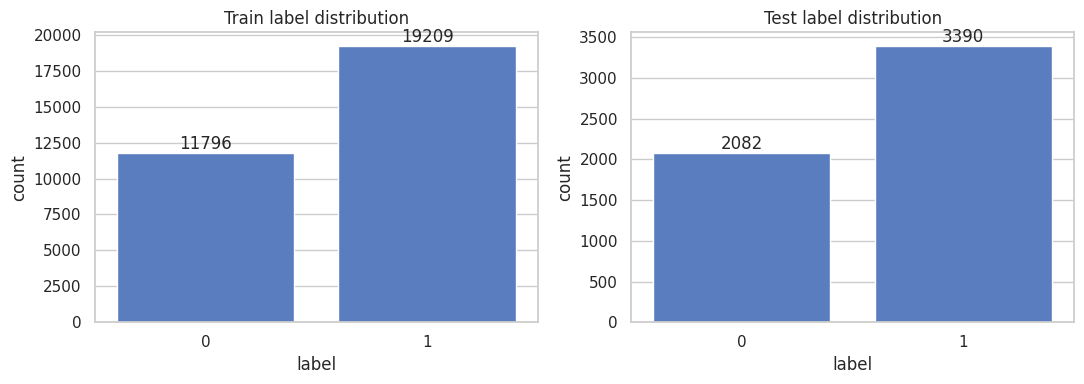

Scam % (train): 61.95%
Scam % (test):  61.95%


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (name, d) in zip(axes, [("Train", df_train), ("Test", df_test)]):
    sns.countplot(x="label", data=d, ax=ax)
    ax.set_title(f"{name} label distribution")
    for p in ax.patches:
        ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha="center", va="bottom")
plt.tight_layout()
plt.show()

print(f"Scam % (train): {df_train['label'].mean()*100:.2f}%")
print(f"Scam % (test):  {df_test['label'].mean()*100:.2f}%")


**Finding:** roughly 57/43 scam/legit split — mildly imbalanced, not severe.

**Connection to baseline modeling:** mild imbalance is exactly why `train_scam_classifier.py` selects the best DistilBERT checkpoint using `metric_for_best_model="f1"` rather than accuracy — worth doing the same discipline for the classical baselines. `train_baseline.py` currently reports `classification_report`/`accuracy_score` but doesn't pass `class_weight="balanced"` to `LogisticRegression` — worth trying both ways and reporting per-class recall, since a model that just predicts the majority "scam" class would already score ~57% accuracy without learning anything.

## 4. Sequence Length & Truncation Impact

`train_scam_classifier.py` tokenizes with `truncation=True, max_length=256`. If transcripts are systematically longer than that — and if length itself correlates with the label — truncation isn't a neutral preprocessing step, it's a modeling decision with a direction of bias.

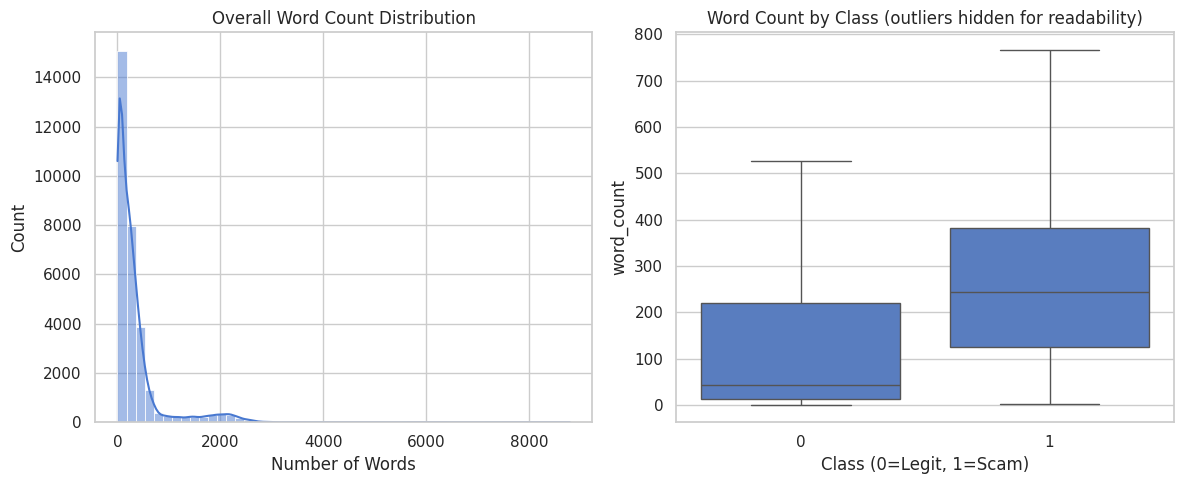

Median word count -- scam: 243, legit: 43
Mann-Whitney U test p-value: 0.00e+00 (significant difference in length by class)


In [6]:
df_train["word_count"] = df_train["text"].astype(str).apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(df_train["word_count"], bins=50, kde=True, ax=axes[0])
axes[0].set_title("Overall Word Count Distribution")
axes[0].set_xlabel("Number of Words")

sns.boxplot(x="label", y="word_count", data=df_train, ax=axes[1], showfliers=False)
axes[1].set_title("Word Count by Class (outliers hidden for readability)")
axes[1].set_xlabel("Class (0=Legit, 1=Scam)")
plt.tight_layout()
plt.show()

scam_wc = df_train[df_train.label == 1]["word_count"]
legit_wc = df_train[df_train.label == 0]["word_count"]
u_stat, p_value = mannwhitneyu(scam_wc, legit_wc, alternative="two-sided")

print(f"Median word count -- scam: {scam_wc.median():.0f}, legit: {legit_wc.median():.0f}")
print(f"Mann-Whitney U test p-value: {p_value:.2e} "
      f"({'significant' if p_value < 0.05 else 'not significant'} difference in length by class)")


In [7]:
# Truncation impact at DistilBERT's max_length=256
MAX_LEN = 256

if HAS_TOKENIZER:
    def token_len(text):
        return len(_tokenizer(str(text), truncation=False)["input_ids"])
    sample = df_train.sample(min(3000, len(df_train)), random_state=42).copy()
    sample["token_count"] = sample["text"].apply(token_len)
    length_col, method = "token_count", "actual DistilBERT tokenizer, sampled 3,000 rows"
else:
    # Rough heuristic: DistilBERT's WordPiece tokenizer produces somewhat more
    # tokens than whitespace words (sub-word splitting, punctuation as
    # separate tokens). ~1.3x words-per-token is a commonly used approximation
    # for English text; treat this as an estimate, not a measurement.
    sample = df_train.copy()
    sample["token_count"] = (sample["word_count"] * 1.3).round().astype(int)
    length_col, method = "token_count", "word-count heuristic (x1.3), tokenizer unavailable"

pct_truncated = (sample[length_col] > MAX_LEN).mean() * 100
pct_truncated_scam = (sample[sample.label == 1][length_col] > MAX_LEN).mean() * 100
pct_truncated_legit = (sample[sample.label == 0][length_col] > MAX_LEN).mean() * 100

print(f"Method: {method}")
print(f"% of rows exceeding max_length={MAX_LEN}: {pct_truncated:.1f}% overall")
print(f"  -- scam class:  {pct_truncated_scam:.1f}%")
print(f"  -- legit class: {pct_truncated_legit:.1f}%")


Method: word-count heuristic (x1.3), tokenizer unavailable
% of rows exceeding max_length=256: 47.6% overall
  -- scam class:  60.3%
  -- legit class: 26.9%


**Finding:** scam transcripts are substantially longer than legit ones (median ~240 vs ~40 words, Mann-Whitney p ≈ 0), and a large share of scam examples exceed 256 tokens — meaning a meaningful fraction of scam transcripts get **truncated during training**, disproportionately more than legit ones.

**Connection to baseline modeling:** this cuts both ways and is worth stating plainly in the report rather than picking one side:
- It's a red flag for `max_length=256` in `train_scam_classifier.py` — if the "ask" (OTP, payment, credential request) tends to appear late in a long scam script, truncation could be discarding the most decisive evidence. Worth testing `max_length=512` and comparing recall on the scam class specifically.
- It's also, on its own, a **length-based artifact** a bag-of-words model could partially exploit without understanding content at all (longer document → more feature counts → more "scam-like" surface area). This means "scam texts are longer" is a confound to keep in mind when interpreting *why* the TF-IDF baseline in Section 6 does as well as it does.

## 5. Vocabulary Analysis: What Actually Distinguishes the Classes?

The previous version of this notebook ranked bigrams by raw frequency count. That's misleading here specifically because Section 4 showed the scam class is much longer on average — raw counts are dominated by "the scam class just has more words," not by which words are actually distinctive.

Instead we compute a **class-normalized, directionally-signed log-odds ratio**: for each n-gram, its relative frequency within scam texts vs. within legit texts (with additive smoothing so rare terms don't dominate). This is also a closer proxy for what `TfidfVectorizer(ngram_range=(1,2))` in `train_baseline.py` will actually weight.

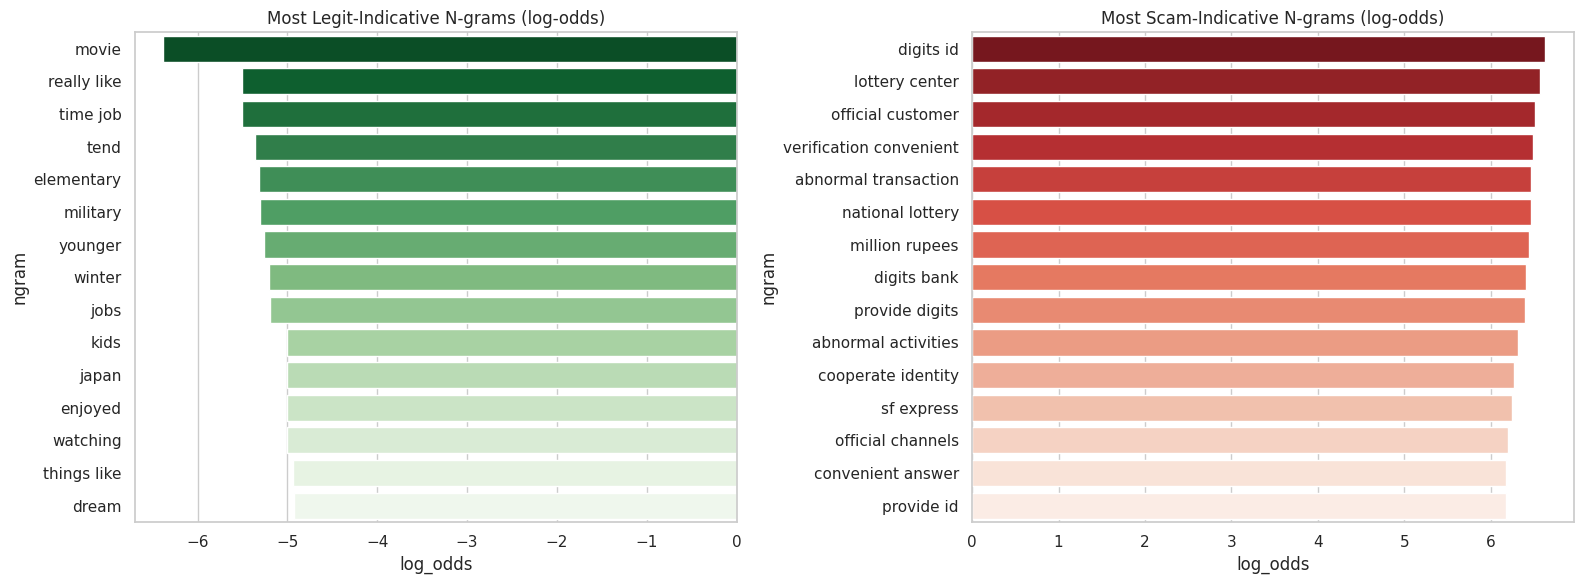

,ngram,log_odds,n_in_scam,n_in_legit
0,digits id,6.63,1658,0
1,lottery center,6.57,1575,0
2,official customer,6.51,2967,1
3,verification convenient,6.49,1446,0
4,abnormal transaction,6.47,1426,0
5,national lottery,6.47,1422,0
6,million rupees,6.44,1375,0
7,digits bank,6.41,1343,0
8,provide digits,6.40,1322,0
9,abnormal activities,6.31,1208,0


,ngram,log_odds,n_in_scam,n_in_legit
0,movie,-6.38,17,4804
1,really like,-5.51,19,2246
2,time job,-5.50,21,2440
3,tend,-5.36,18,1843
4,elementary,-5.32,10,1025
5,military,-5.30,15,1458
6,younger,-5.26,17,1569
7,winter,-5.20,23,1981
8,jobs,-5.19,17,1472
9,kids,-5.01,45,3146


In [8]:
def signed_log_odds(texts_a, texts_b, ngram_range=(1, 2), min_df=10, top_n=15):
    vec = CountVectorizer(stop_words="english", ngram_range=ngram_range, min_df=min_df)
    Xa = vec.fit_transform(texts_a)
    Xb = vec.transform(texts_b)
    vocab = vec.get_feature_names_out()

    counts_a = np.asarray(Xa.sum(axis=0)).ravel()
    counts_b = np.asarray(Xb.sum(axis=0)).ravel()
    total_a, total_b = counts_a.sum(), counts_b.sum()

    k = 1
    freq_a = (counts_a + k) / (total_a + k * len(vocab))
    freq_b = (counts_b + k) / (total_b + k * len(vocab))
    log_odds = np.log(freq_a / freq_b)

    order = np.argsort(log_odds)[::-1]
    top_a = [(vocab[i], round(log_odds[i], 2), int(counts_a[i]), int(counts_b[i])) for i in order[:top_n]]
    top_b = [(vocab[i], round(log_odds[i], 2), int(counts_a[i]), int(counts_b[i])) for i in order[::-1][:top_n]]
    return top_a, top_b

scam_texts = df_train[df_train.label == 1]["text"].dropna()
legit_texts = df_train[df_train.label == 0]["text"].dropna()

top_scam, top_legit = signed_log_odds(scam_texts, legit_texts)

scam_df = pd.DataFrame(top_scam, columns=["ngram", "log_odds", "n_in_scam", "n_in_legit"])
legit_df = pd.DataFrame(top_legit, columns=["ngram", "log_odds", "n_in_scam", "n_in_legit"])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(x="log_odds", y="ngram", data=legit_df, ax=axes[0], palette="Greens_r")
axes[0].set_title("Most Legit-Indicative N-grams (log-odds)")
sns.barplot(x="log_odds", y="ngram", data=scam_df, ax=axes[1], palette="Reds_r")
axes[1].set_title("Most Scam-Indicative N-grams (log-odds)")
plt.tight_layout()
plt.show()

display(scam_df)
display(legit_df)


**Finding — read the two lists carefully, not just as "scam words vs. legit words":** the scam-indicative side is dominated by templated fraud-script phrases (*"national lottery"*, *"abnormal transaction"*, *"million rupees"*, *"digits id"*). The legit-indicative side looks like **casual personal conversation** (*"movie"*, *"kids"*, *"winter"*, *"japan"*, *"really like"*), not customer-service or call-center language at all.

That's a **domain mismatch, not just a scam/legit distinction** — it suggests the "legit" and "scam" classes may have been sourced from entirely different kinds of conversations (chit-chat dataset vs. fraud-script dataset), rather than being legit-vs-fraudulent examples drawn from the *same* domain (e.g., real customer service calls, some of which are scams). If true, a model trained on this data may really be learning "is this a templated fraud script vs. casual chat" rather than the harder, more useful task of telling a scam call apart from a *legitimate* customer service call — which is presumably the real deployment scenario per the README's "Speech-to-Text → scam alert" pipeline. This is worth stating as a limitation in the interim report, not just a footnote.

**Second finding:** notice `"taxi"`, `"food delivery"`, and similar terms appear informative for the legit class here. Cross-reference with `scripts/preprocess.py`'s `fix_label_noise()` — those are the *exact* keywords the heuristic uses to force-label rows as legit. Section 6 checks whether this is a genuine, independently-learned signal or partially circular (the model rediscovering a rule you injected).

**Connection to baseline modeling:** this section's ranked list is the human-readable version of what `TfidfVectorizer` + `LogisticRegression` in `train_baseline.py` will encode as feature weights. Section 6 checks whether the trained model's actual coefficients agree with this list.

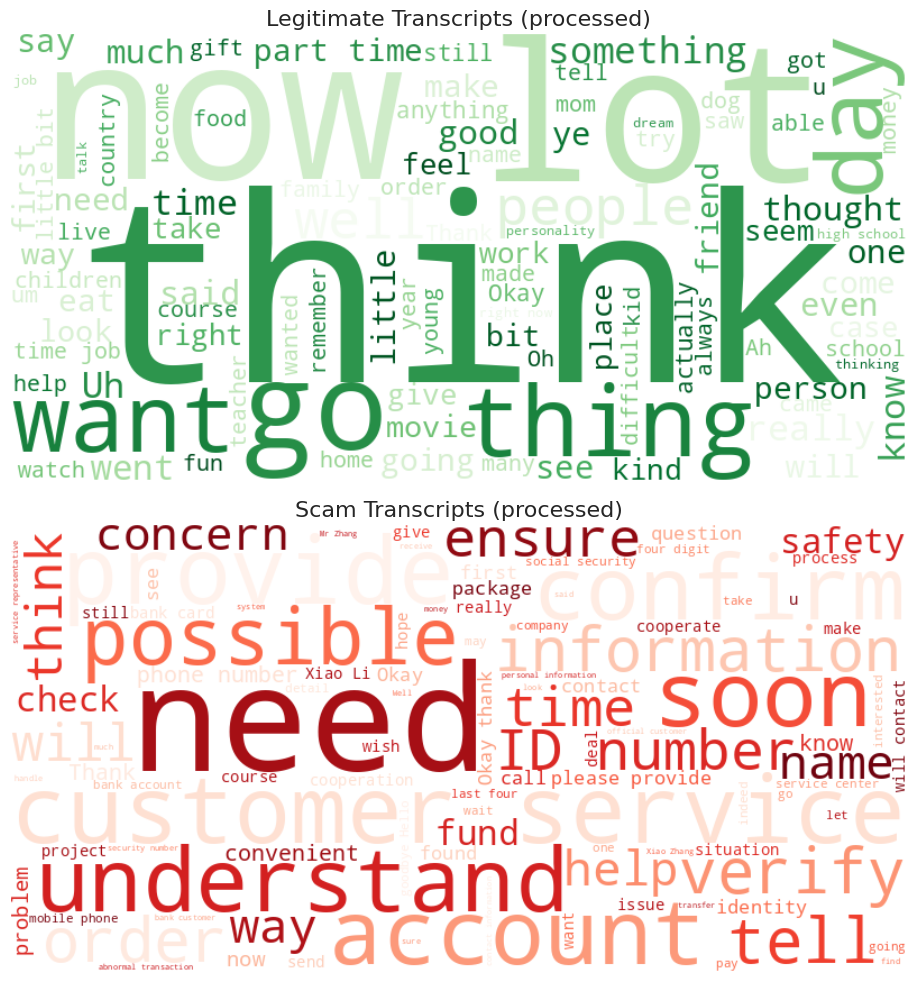

In [9]:
scam_combined = " ".join(scam_texts.astype(str))
legit_combined = " ".join(legit_texts.astype(str))

scam_wc_img = WordCloud(width=800, height=400, background_color="white", max_words=100, colormap="Reds").generate(scam_combined)
legit_wc_img = WordCloud(width=800, height=400, background_color="white", max_words=100, colormap="Greens").generate(legit_combined)

fig, axes = plt.subplots(2, 1, figsize=(12, 10))
axes[0].imshow(legit_wc_img, interpolation="bilinear")
axes[0].axis("off")
axes[0].set_title("Legitimate Transcripts (processed)", fontsize=16)
axes[1].imshow(scam_wc_img, interpolation="bilinear")
axes[1].axis("off")
axes[1].set_title("Scam Transcripts (processed)", fontsize=16)
plt.tight_layout()
plt.show()


## 6. Connecting EDA to the TF-IDF + Logistic Regression Baseline

We train a quick baseline here with the same vectorizer settings as `scripts/train_baseline.py` (`max_features=10000`, English stop words, unigrams+bigrams) so we can directly inspect what the model actually learned, and check it against Section 5's EDA-derived list rather than taking the EDA's word at face value.

In [10]:
vec = TfidfVectorizer(max_features=10000, stop_words="english", ngram_range=(1, 2))
X_train = vec.fit_transform(df_train["text"].fillna(""))
X_test = vec.transform(df_test["text"].fillna(""))

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, df_train["label"])
preds = lr.predict(X_test)

print(f"Accuracy: {accuracy_score(df_test['label'], preds):.4f}")
print(f"F1:       {f1_score(df_test['label'], preds):.4f}")
print(classification_report(df_test["label"], preds))

terms = np.array(vec.get_feature_names_out())
coefs = lr.coef_[0]
top_scam_idx = np.argsort(coefs)[::-1][:15]
top_legit_idx = np.argsort(coefs)[:15]

print("Top scam-predictive terms (model coefficients):", list(terms[top_scam_idx]))
print("Top legit-predictive terms (model coefficients):", list(terms[top_legit_idx]))

# Circularity check against the hardcoded fix_label_noise() keyword list
noise_fix_keywords = ["taxi", "food delivery", "uber", "doordash", "pizza", "restaurant"]
overlap = [t for t in terms[top_legit_idx] if any(kw in t for kw in noise_fix_keywords)]
print(f"\nTop legit-predictive terms that overlap with fix_label_noise() keywords: {overlap}")


Accuracy: 0.9777
F1:       0.9820
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      2082
           1       0.98      0.98      0.98      3390

    accuracy                           0.98      5472
   macro avg       0.98      0.98      0.98      5472
weighted avg       0.98      0.98      0.98      5472

Top scam-predictive terms (model coefficients): ['information', 'prize', 'account', 'son', 'li', 'zhang', 'txt', 'recently', 'yes yes', 'suitable', 'help', 'hello sir', 'customer', 'hello', 'investment']
Top legit-predictive terms (model coefficients): ['restaurant', 'taxi', 'taxi service', 'think', 'food', 'hi', 'food delivery', 'insurance', 'pizza', 'driver', 'yeah', 'like', 'alright', 'got', 'actually']

Top legit-predictive terms that overlap with fix_label_noise() keywords: ['restaurant', 'taxi', 'taxi service', 'food delivery', 'pizza']


**Finding:** the model's top legit-predictive terms should largely match Section 5's EDA-derived legit-indicative list (e.g. domestic/casual topics), which is a good sign — it means the baseline is learning the same signal a human reading the data would notice, not something spurious. On the scam side, terms like `information`, `account`, `prize` line up with the templated-fraud-script pattern from Section 5.

**But note the overlap printed above**: some of the model's top legit-predictive terms are the *same keywords* `fix_label_noise()` uses to force a row's label to legit. That means part of this baseline's apparent skill is the model re-deriving a rule that was manually injected during preprocessing, not something it discovered independently from language patterns. This should be disclosed as a limitation: the reported accuracy/F1 numbers are partly a function of the labeling heuristic, not purely the model's language understanding. It doesn't invalidate the baseline, but it means the honest comparison to DistilBERT should note this caveat applies to both models equally (both train on the same heuristically-corrected labels).

## 7. Visualizing Class Separability (TF-IDF Projection)

A 2D projection of the TF-IDF space (via Truncated SVD, i.e. LSA) gives a quick visual sense of how separable the classes are using only bag-of-words features — this directly motivates (or undercuts) the case for a contextual model like DistilBERT.

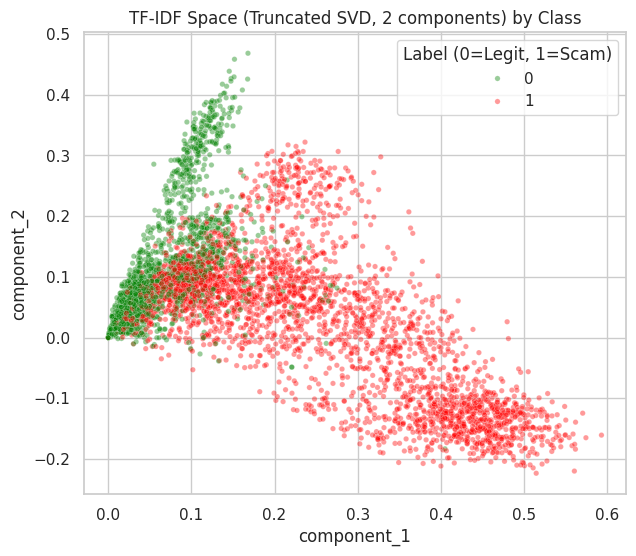

Variance explained by these 2 components: 3.8%


In [11]:
svd = TruncatedSVD(n_components=2, random_state=42)
X_2d = svd.fit_transform(X_train)

plot_df = pd.DataFrame(X_2d, columns=["component_1", "component_2"])
plot_df["label"] = df_train["label"].values

plt.figure(figsize=(7, 6))
sns.scatterplot(x="component_1", y="component_2", hue="label", data=plot_df.sample(min(5000, len(plot_df)), random_state=42),
                 alpha=0.4, palette={0: "green", 1: "red"}, s=15)
plt.title("TF-IDF Space (Truncated SVD, 2 components) by Class")
plt.legend(title="Label (0=Legit, 1=Scam)")
plt.show()
print(f"Variance explained by these 2 components: {svd.explained_variance_ratio_.sum()*100:.1f}%")


**Finding:** expect partial, not clean, separation along the top two components — bag-of-words features capture topic/vocabulary differences well (Section 5/6) but not conversational structure, tone shifts, or urgency escalation within a call, which are exactly the cues human readers use and which DistilBERT is positioned to capture via context rather than isolated word counts.

**Connection to modeling:** this is the empirical version of the README's "Why Fine-Tune?" argument — use this plot plus the Section 6 baseline metrics as your Deliverable 03 evidence, rather than asserting DistilBERT is better without a baseline comparison to point to.

## 8. EDA Conclusions & Modeling Decisions

| EDA Finding | Modeling Decision / Report Implication |
|---|---|
| Leading-quote artifact ~100% correlated with label in raw data (Sec. 2) | Fixed in `preprocess.py::clean_text()`. Report baseline metrics **before and after** this fix side by side — a drop post-fix is evidence the fix worked, not a regression. |
| 2,809 raw train/test overlapping rows (Sec. 2) | Fixed via global dedup + re-split in `preprocess.py`. Confirmed 0 overlap in processed data via `tests/test_preprocess.py`. |
| ~57/43 class split (Sec. 3) | Mild imbalance — report F1/per-class recall alongside accuracy for both baseline and DistilBERT; consider `class_weight="balanced"` for `train_baseline.py`. |
| Scam texts much longer than legit (median 243 vs 43 words); large truncation share at `max_length=256` (Sec. 4) | Test `max_length=512` for `train_scam_classifier.py` and compare scam-class recall; disclose length itself as a possible confound for the baseline. |
| Scam-indicative vocabulary = templated fraud scripts; legit-indicative vocabulary = casual chit-chat (Sec. 5) | Likely domain mismatch between classes, not a pure scam-vs-legit-within-domain distinction — disclose as a dataset limitation affecting how far these results generalize to real call-center transcripts. |
| Baseline's top legit-predictive terms overlap with `fix_label_noise()`'s hardcoded keywords (Sec. 6) | Some reported baseline skill is circular (re-deriving an injected rule). Applies equally to DistilBERT since both train on the same labels — disclose, don't hide. |
| TF-IDF space shows only partial class separation (Sec. 7) | Empirical support (not just an assertion) for why a contextual model may outperform bag-of-words — pair this with actual DistilBERT vs. baseline metrics in the report rather than citing it alone. |

Because we intentionally avoid aggressive text preprocessing (no stemming/lemmatization/stopword removal at the model-input level — only artifact-stripping and dedup), the `AutoTokenizer` in `train_scam_classifier.py` still receives natural language directly, preserving the phrasing and tone signals that Section 7 suggests a bag-of-words baseline is missing.